# Прогнозирование рейтинга настольных игр

### Задача
Разработать алгоритм (модель машинного обучения), который сможет предсказывать средний рейтинг игры.

### Данные:
- `data/train_data.csv` -> тренировочный набор данных
- `data/test_data.csv` -> тестовый набор данных

### Целевая переменная:
- `Rating Average` -> предсказать число, задача регрессии

### Основная метрика:
- `MSE` -> средняя квадратичная ошибка

### План решения задачи
1. Загрузить данные и изучить структуру.
2. Привести признаки к корректным типам.
3. Обработать пропуски и категориальные признаки.
4. Построить модель.
5. Улучшить обработку признаков.
6. Сравнить несколько моделей.
7. Подготовить итоговый submission и загрузить на Kaggle.

# Импортируем необходимые библиотеки

In [50]:
# Библиотека для работы с предупреждениями
import warnings
# Библиотеки для работы с данными
import numpy as np
import pandas as pd
from collections import Counter
# Библиотеки для визуализации
import matplotlib.pyplot as plt
import seaborn as sns
# Разделение данных и оценка качества
from sklearn.model_selection import train_test_split
# Метрики регрессии
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Препроцессинг (обработка данных)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.impute import SimpleImputer
# Классы с моделями
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeRegressor

# Убираем шум по лишним предупреждениям
warnings.filterwarnings('ignore')

# Настраиваем отображение таблиц
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

# Настраиваем тему графиков
sns.set_theme(
    style='darkgrid',
    context='notebook',
    rc={'figure.figsize': (10, 6)}
)

# Загружаем данные

In [51]:
# Загружаем тренировочный датасет
train = pd.read_csv('data/train_data.csv')

# Загружаем тестовый датасет
test = pd.read_csv('data/test_data.csv')

# Смотрим размеры датасетов
print(f'Train data: {train.shape}')
print(f'Test data: {test.shape}')

Train data: (15257, 14)
Test data: (5086, 13)


# Анализируем данные из датасетов

In [52]:
# Смотрим первые строки train
train.head()

,ID,Name,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains
0,174430.0,Gloomhaven,2017.0,1,4,120,14,42055,"8,79",1,"3,86",68323.0,"Action Queue, Action Retrieval, Campaign / Bat...","Strategy Games, Thematic Games"
1,224517.0,Brass: Birmingham,2018.0,2,4,120,14,19217,"8,66",3,"3,91",28785.0,"Hand Management, Income, Loans, Market, Networ...",Strategy Games
2,167791.0,Terraforming Mars,2016.0,1,5,120,12,64864,"8,43",4,"3,24",87099.0,"Card Drafting, Drafting, End Game Bonuses, Han...",Strategy Games
3,233078.0,Twilight Imperium: Fourth Edition,2017.0,3,6,480,14,13468,"8,70",5,"4,22",16831.0,"Action Drafting, Area Majority / Influence, Ar...","Strategy Games, Thematic Games"
4,291457.0,Gloomhaven: Jaws of the Lion,2020.0,1,4,120,14,8392,"8,87",6,"3,55",21609.0,"Action Queue, Campaign / Battle Card Driven, C...","Strategy Games, Thematic Games"


In [53]:
# Смотрим первые строки test
test.head()

,ID,Name,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains
0,161936.0,Pandemic Legacy: Season 1,2015.0,2,4,60,13,41643,2,"2,84",65294.0,"Action Points, Cooperative Game, Hand Manageme...","Strategy Games, Thematic Games"
1,12333.0,Twilight Struggle,2005.0,2,2,180,13,40814,10,"3,59",56219.0,"Action/Event, Advantage Token, Area Majority /...","Strategy Games, Wargames"
2,115746.0,War of the Ring: Second Edition,2012.0,2,4,180,13,13725,12,"4,14",22281.0,"Area Majority / Influence, Area Movement, Camp...","Thematic Games, Wargames"
3,169786.0,Scythe,2016.0,1,5,115,14,57871,14,"3,41",75640.0,"Area Majority / Influence, Card Play Conflict ...",Strategy Games
4,28720.0,Brass: Lancashire,2007.0,2,4,120,14,19400,19,"3,86",25429.0,"Hand Management, Income, Loans, Network and Ro...",Strategy Games


In [54]:
# Общая информация по train
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15257 entries, 0 to 15256
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  15247 non-null  float64
 1   Name                15257 non-null  object 
 2   Year Published      15256 non-null  float64
 3   Min Players         15257 non-null  int64  
 4   Max Players         15257 non-null  int64  
 5   Play Time           15257 non-null  int64  
 6   Min Age             15257 non-null  int64  
 7   Users Rated         15257 non-null  int64  
 8   Rating Average      15257 non-null  object 
 9   BGG Rank            15257 non-null  int64  
 10  Complexity Average  15257 non-null  object 
 11  Owned Users         15240 non-null  float64
 12  Mechanics           14057 non-null  object 
 13  Domains             7608 non-null   object 
dtypes: float64(3), int64(6), object(5)
memory usage: 1.6+ MB


In [55]:
# Общая информация по test
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5086 entries, 0 to 5085
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5080 non-null   float64
 1   Name                5086 non-null   object 
 2   Year Published      5086 non-null   float64
 3   Min Players         5086 non-null   int64  
 4   Max Players         5086 non-null   int64  
 5   Play Time           5086 non-null   int64  
 6   Min Age             5086 non-null   int64  
 7   Users Rated         5086 non-null   int64  
 8   BGG Rank            5086 non-null   int64  
 9   Complexity Average  5086 non-null   object 
 10  Owned Users         5080 non-null   float64
 11  Mechanics           4688 non-null   object 
 12  Domains             2576 non-null   object 
dtypes: float64(3), int64(6), object(4)
memory usage: 516.7+ KB


In [56]:
# Смотрим пропуски в train
train_missing = train.isna().sum()
train_missing[train_missing > 0].sort_values(ascending=False)

Domains           7649
Mechanics         1200
Owned Users         17
ID                  10
Year Published       1
dtype: int64

In [57]:
# Смотрим пропуски в test
test_missing = test.isna().sum()
test_missing[test_missing > 0].sort_values(ascending=False)

Domains        2510
Mechanics       398
ID                6
Owned Users       6
dtype: int64

In [58]:
# Смотрим и считаем дубликаты
print(f'Train duplicates: {train.duplicated().sum()}')
print(f'Test duplicates: {test.duplicated().sum()}')

Train duplicates: 0
Test duplicates: 0


In [59]:
# Смотрим список колонок
train.columns

Index(['ID', 'Name', 'Year Published', 'Min Players', 'Max Players',
       'Play Time', 'Min Age', 'Users Rated', 'Rating Average', 'BGG Rank',
       'Complexity Average', 'Owned Users', 'Mechanics', 'Domains'],
      dtype='object')

In [60]:
# Смотрим стату по числовым признакам
train.describe()

,ID,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,BGG Rank,Owned Users
count,15247.000000,15256.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15240.000000
mean,108221.590214,1984.144140,2.021236,5.642918,92.801337,9.581766,819.530773,10186.327784,1372.209843
std,98862.566448,211.725679,0.696323,12.551944,607.611378,3.671560,3286.396397,5863.744570,4681.296849
min,1.000000,-3500.000000,0.000000,0.000000,0.000000,0.000000,30.000000,1.000000,0.000000
25%,10907.000000,2001.000000,2.000000,4.000000,30.000000,8.000000,55.000000,5103.000000,146.000000
50%,88316.000000,2011.000000,2.000000,4.000000,45.000000,10.000000,119.000000,10171.000000,308.000000
75%,193045.500000,2016.000000,2.000000,6.000000,90.000000,12.000000,379.000000,15280.000000,856.250000
max,331787.000000,2022.000000,10.000000,999.000000,60000.000000,25.000000,102214.000000,20344.000000,155312.000000


In [61]:
# Смотрим стату по категориальным признакам
train.describe(include='object')

,Name,Rating Average,Complexity Average,Mechanics,Domains
count,15257,15257,15257,14057,7608
unique,15045,610,377,5898,39
top,Robin Hood,"6,50",1,Hand Management,Wargames
freq,6,89,1723,327,2236


## Краткие выводы после анализа датасетов

Размеры данных:
- Train: 15257 строк х 14 колонок
- Test: 5086 строк х 13 колонок

В тестовом наборе отсутствует целевая переменная `Rating Average`.

В данных выявлены следующие особенности:
- `Rating Average` и `Complexity Average` имеют тип `object`, но по своему смыслудолжны быть числовыми признаками
- десятичный разделитель записан через запятую, значит их нужно преобразовать в float
- в полях `Domains`, `Mechanics`, `Owned Users`, `ID`, `Year Published` есть пропуски, значит их нужно обработать
- несмотря на то, что `Domains` имеет множество пропусков, попробуем его обработать, так как он может быть полезен, удалять не будем
- поля `Mechanics` и `Domains` имеют значения через запятую, поэтому их нужно обработать как мультикатегориальные признаки
- дубликатов в данных не обнаружено

# Приводим данные к корректным типам

In [62]:
# Создаем копии, чтобы не изменять исходные датасеты
train_copy = train.copy()
test_copy = test.copy()

# Получаем строковые колонки, которые нужно преобразовать в float
decimal_cols = ['Rating Average', 'Complexity Average']

# Преобразуем Rating Average
train_copy['Rating Average'] = (
    train_copy['Rating Average']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

# Преобразуем Complexity Average
for df in [train_copy, test_copy]:
    df['Complexity Average'] = (
        df['Complexity Average']
        .astype(str)
        .str.replace(',', '.', regex=False)
        .astype(float)
    )

# Проверяем результат
train_copy[['Rating Average', 'Complexity Average']].dtypes

Rating Average        float64
Complexity Average    float64
dtype: object

In [63]:
# Проверяем train после обработки
train_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15257 entries, 0 to 15256
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  15247 non-null  float64
 1   Name                15257 non-null  object 
 2   Year Published      15256 non-null  float64
 3   Min Players         15257 non-null  int64  
 4   Max Players         15257 non-null  int64  
 5   Play Time           15257 non-null  int64  
 6   Min Age             15257 non-null  int64  
 7   Users Rated         15257 non-null  int64  
 8   Rating Average      15257 non-null  float64
 9   BGG Rank            15257 non-null  int64  
 10  Complexity Average  15257 non-null  float64
 11  Owned Users         15240 non-null  float64
 12  Mechanics           14057 non-null  object 
 13  Domains             7608 non-null   object 
dtypes: float64(5), int64(6), object(3)
memory usage: 1.6+ MB


In [64]:
# Смотрим test после преобразования
test_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5086 entries, 0 to 5085
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5080 non-null   float64
 1   Name                5086 non-null   object 
 2   Year Published      5086 non-null   float64
 3   Min Players         5086 non-null   int64  
 4   Max Players         5086 non-null   int64  
 5   Play Time           5086 non-null   int64  
 6   Min Age             5086 non-null   int64  
 7   Users Rated         5086 non-null   int64  
 8   BGG Rank            5086 non-null   int64  
 9   Complexity Average  5086 non-null   float64
 10  Owned Users         5080 non-null   float64
 11  Mechanics           4688 non-null   object 
 12  Domains             2576 non-null   object 
dtypes: float64(4), int64(6), object(3)
memory usage: 516.7+ KB


# Анализируем целевую переменную

In [65]:
# Стата по целевой переменной
train_copy['Rating Average'].describe()

count    15257.000000
mean         6.399775
std          0.936488
min          1.050000
25%          5.820000
50%          6.430000
75%          7.020000
max          9.580000
Name: Rating Average, dtype: float64

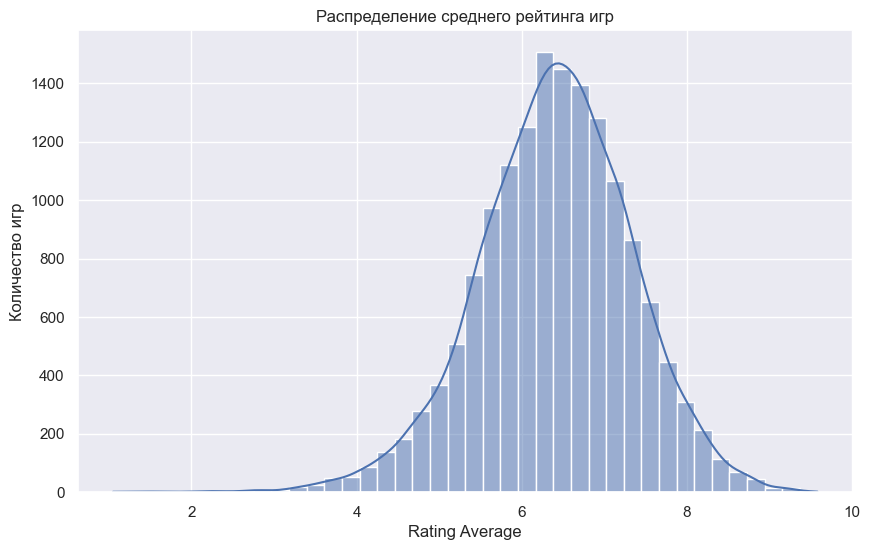

In [66]:
# Строим распределение рейтинга
sns.histplot(train_copy['Rating Average'], bins=40, kde=True)

plt.title('Распределение среднего рейтинга игр')
plt.xlabel('Rating Average')
plt.ylabel('Количество игр')
plt.show()

In [67]:
# Проверяем самые низкие и самые высокие рейтинги
display(
    train_copy
    .sort_values('Rating Average')
    [['Name', 'Rating Average', 'Users Rated', 'BGG Rank']]
    .head(10)
)

display(
    train_copy
    .sort_values('Rating Average', ascending=False)
    [['Name', 'Rating Average', 'Users Rated', 'BGG Rank']]
    .head(10)
)

,Name,Rating Average,Users Rated,BGG Rank
15153,Oneupmanship: Mine's Bigger,1.05,67,20205
15215,Alien: USCSS Nostromo,1.10,263,20288
14971,Rock Paper Scissors Game,1.32,30,19959
15048,W.W.B,1.43,41,20070
15110,Intelligent Design vs. Evolution,1.54,57,20151
15129,Overturn: Rising Sands,1.55,75,20176
15011,Ms. Monopoly,1.78,39,20009
15195,Global Survival,1.90,120,20261
15143,Super Deck!,2.06,76,20195
15082,Time Control,2.14,53,20113


,Name,Rating Average,Users Rated,BGG Rank
10953,Erune,9.58,31,14598
7689,Star Trek: Alliance - Dominion War Campaign,9.46,54,10248
10169,Aeolis,9.43,37,13549
8617,Company of Heroes,9.34,47,11482
5351,Wings of the Motherland,9.31,79,7193
9204,Deliverance,9.25,34,12246
11816,War Titans: Invaders Must Die!,9.24,58,15786
10593,Gladiatoris,9.23,31,14125
8609,Sheol,9.23,64,11472
10061,Tindaya,9.22,30,13401


# Проверяем выбросы

In [68]:
# Список основных числовых признаков
numeric_cols = [
    'Year Published',
    'Min Players',
    'Max Players',
    'Play Time',
    'Min Age',
    'Users Rated',
    'BGG Rank',
    'Complexity Average',
    'Owned Users'
]

# Смотрим статистику после преобразования типов
train_copy[numeric_cols + ['Rating Average']].describe()

,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,BGG Rank,Complexity Average,Owned Users,Rating Average
count,15256.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15240.000000,15257.000000
mean,1984.144140,2.021236,5.642918,92.801337,9.581766,819.530773,10186.327784,1.991064,1372.209843,6.399775
std,211.725679,0.696323,12.551944,607.611378,3.671560,3286.396397,5863.744570,0.848816,4681.296849,0.936488
min,-3500.000000,0.000000,0.000000,0.000000,0.000000,30.000000,1.000000,0.000000,0.000000,1.050000
25%,2001.000000,2.000000,4.000000,30.000000,8.000000,55.000000,5103.000000,1.330000,146.000000,5.820000
50%,2011.000000,2.000000,4.000000,45.000000,10.000000,119.000000,10171.000000,2.000000,308.000000,6.430000
75%,2016.000000,2.000000,6.000000,90.000000,12.000000,379.000000,15280.000000,2.540000,856.250000,7.020000
max,2022.000000,10.000000,999.000000,60000.000000,25.000000,102214.000000,20344.000000,5.000000,155312.000000,9.580000


In [69]:
# Смотрим минимальные значения по потенциально проблемным колонкам
problem_cols = ['Year Published', 'Min Players', 'Max Players', 'Play Time', 'Min Age']

for col in problem_cols:
    print(f'\n{col}')
    display(
        train_copy
        .sort_values(col)
        [['Name', col, 'Rating Average', 'Users Rated', 'BGG Rank']]
        .head(10)
    )


Year Published


,Name,Year Published,Rating Average,Users Rated,BGG Rank
6088,Senet,-3500.0,5.82,664,8176
123,Go,-2200.0,7.64,14843,173
14740,Three Men's Morris,-1400.0,4.31,60,19650
15007,Nine Men's Morris,-1400.0,5.36,1310,20004
15256,Tic-Tac-Toe,-1300.0,2.68,3275,20344
15255,Chutes and Ladders,-200.0,2.86,3783,20343
11343,Petteia,-100.0,6.01,51,15136
8972,Miscellaneous Game Book,0.0,6.66,41,11951
9062,Miscellaneous Game Magazine,0.0,7.04,30,12074
14393,Brew-opoly,0.0,4.34,45,19184



Min Players


,Name,Min Players,Rating Average,Users Rated,BGG Rank
10810,Ataxx,0,6.07,48,14403
14544,The Da Vinci Code Game,0,4.86,68,19382
9062,Miscellaneous Game Magazine,0,7.04,30,12074
7445,China: The Middle Kingdom,0,6.81,71,9929
6848,The Badger Deck,0,8.27,36,9169
9048,Eden: Survive the Apocalypse,0,7.84,35,12056
2107,Unpublished Prototype,0,6.90,804,2841
14643,Monopoly: Marvel Comics,0,4.60,78,19519
9597,"Lille: The Classic Vauban Siege, 1708",0,6.72,37,12768
2398,Stonewall Jackson's Way II: Battles of Bull Run,0,8.57,218,3224



Max Players


,Name,Max Players,Rating Average,Users Rated,BGG Rank
13658,VH1 Pop Up Video Game,0,4.92,42,18227
14219,Klugscheisser,0,4.46,41,18943
14222,SongBurst 50's & 60's Edition,0,5.17,105,18946
9038,Roliça et Vimeiro 1808,0,7.57,30,12039
13242,Screwball Scramble,0,5.54,320,17666
14908,Quartett,0,4.47,106,19866
8193,Dark Future,0,5.89,281,10924
7191,Flying Lead,0,7.36,47,9597
8195,Mentalis,0,7.66,32,10929
9947,Oodles of Doodles,0,6.20,57,13248



Play Time


,Name,Play Time,Rating Average,Users Rated,BGG Rank
7883,End of the Iron Dream,0,6.89,60,10511
11418,Michigan Rummy,0,5.78,76,15242
11410,"Holy Roman Empire: Wars of the Reformation, 15...",0,6.06,36,15230
11354,Fanhunter Batallitas,0,6.27,33,15151
11339,Sabacc,0,6.14,50,15132
11319,Sort it Out!,0,5.80,75,15104
11292,King Maker,0,6.34,30,15066
11268,Final War,0,6.95,30,15032
11256,Soldier Raj,0,6.13,39,15016
14021,Hatch: the Dragonology Card Game,0,4.94,48,18688



Min Age


,Name,Min Age,Rating Average,Users Rated,BGG Rank
14225,Trailer Park Gods,0,4.73,56,18949
10046,Esagek,0,6.43,45,13378
14070,Zero Hour: Survival Horror Card Game,0,4.55,35,18752
10049,À la charge: Normands et Byzantins,0,7.02,30,13385
10051,Wykersham,0,6.52,38,13389
14067,The Wrong Game,0,4.59,32,18748
10058,AmuseAmaze,0,5.78,124,13396
10072,What's That on My Head?,0,6.37,39,13416
10077,Finger Ball,0,6.13,61,13423
10082,Regista,0,6.40,46,13429


# Анализируем связь числовых признаков с рейтингом

In [70]:
# Корреляция числовых признаков с целевой переменной
corr_with_target = (
    train_copy[numeric_cols + ['Rating Average']]
    .corr(numeric_only=True)['Rating Average']
    .sort_values(ascending=False)
)

corr_with_target

Rating Average        1.000000
Complexity Average    0.470200
Min Age               0.187403
Owned Users           0.184917
Users Rated           0.175867
Play Time             0.080006
Year Published        0.079546
Max Players          -0.043786
Min Players          -0.158291
BGG Rank             -0.737897
Name: Rating Average, dtype: float64

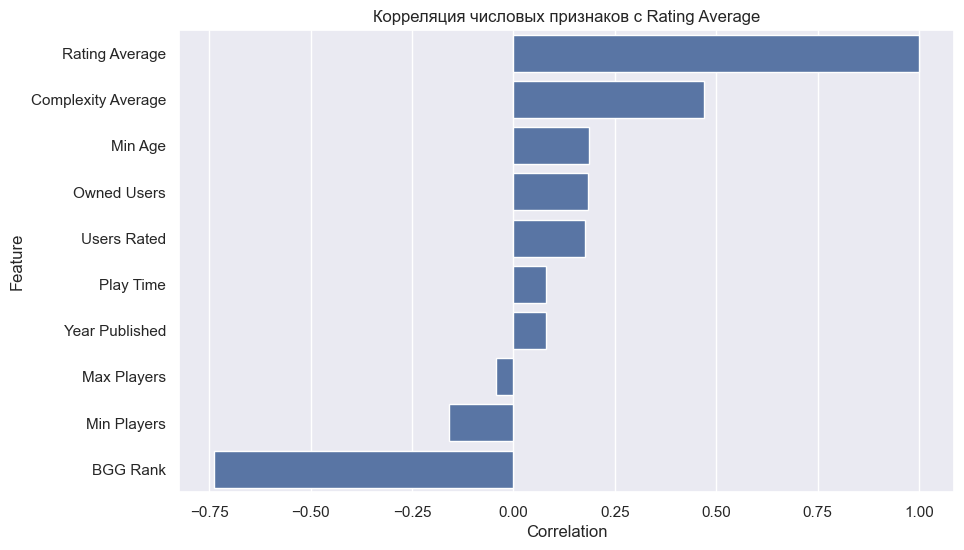

In [71]:
# Визуализируем корреляции
sns.barplot(
    x=corr_with_target.values,
    y=corr_with_target.index
)

plt.title('Корреляция числовых признаков с Rating Average')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.show()

## Краткие выводы по анализу

Дополнительный анализ данных показал:

1. Целевая переменная `Rating Average` имеет распределение, которое близкое к нормальному:
   - основная масса игр имеет рейтинг примерно от 5.8 до 7.0
   - присутствуют выбросы, редкие игры с очень низким и очень высоким рейтингом

2. Признак `BGG Rank` имеет сильную отрицательную связь с рейтингом:
   - чем меньше ранг игры, тем выше средний рейтинг
   - этот признак скорее всего будет важнейшим для модели

3. Признак `Complexity Average` имеет заметную положительную связь с рейтингом:
   - более сложные игры в среднем получают более высокий рейтинг

4. В данных есть проблемные значения:
   - отрицательные и нулевые годы публикации
   - нулевое количество игроков
   - слишком большие значения `Max Players` и `Play Time`

5. Категориальные признаки `Mechanics` и `Domains` имеют множественные значения через запятую.

# Подготовим данные для обучения модели

План:
- обработаем некорректные значения
- создадим дополнительные признаки
- отдельно обработаем списочные признаки `Mechanics` и `Domains`

In [72]:
# Создаем копии данных для дальнейшей подготовки
train_features = train_copy.copy()
test_features = test_copy.copy()

print(f'Train features: {train_features.shape}')
print(f'Test features: {test_features.shape}')

Train features: (15257, 14)
Test features: (5086, 13)


## Обработаем некорректные значения

В данных есть значения, которые некорректно отображают действительное состояние:

- `Year Published` <= 0 -> старые игры или ошибки заполнения
- `Min Players` = 0 -> некорректное минимальное количество игроков
- `Max Players` = 999 -> условное значение для игр с большим количеством игроков
- слишком большой `Play Time`

In [73]:
def fix_num_anomal(df: pd.DataFrame) -> pd.DataFrame:
    """
    Исправляет аномалии в числовых признаках и добавляет флаги.
    Функция применяется к train и test.
    """
    df = df.copy()

    # Флаги проблемных значений
    df['is_old_or_unknown_year'] = (df['Year Published'] <= 0).astype(int)
    df['has_zero_min_players'] = (df['Min Players'] <= 0).astype(int)
    df['has_extreme_max_players'] = (df['Max Players'] > 50).astype(int)
    df['has_extreme_play_time'] = (df['Play Time'] > 1000).astype(int)

    # Исправляем явно некорректные значения
    df.loc[df['Year Published'] <= 0, 'Year Published'] = np.nan
    df.loc[df['Min Players'] <= 0, 'Min Players'] = np.nan

    # Ограничиваем сильные выбросы сверху
    df['Max Players'] = df['Max Players'].clip(upper=50)
    df['Play Time'] = df['Play Time'].clip(upper=1000)

    return df


train_features = fix_num_anomal(train_features)
test_features = fix_num_anomal(test_features)

train_features[
    [
        'Year Published',
        'Min Players',
        'Max Players',
        'Play Time',
        'is_old_or_unknown_year',
        'has_zero_min_players',
        'has_extreme_max_players',
        'has_extreme_play_time'
    ]
].describe()

,Year Published,Min Players,Max Players,Play Time,is_old_or_unknown_year,has_zero_min_players,has_extreme_max_players,has_extreme_play_time
count,15106.000000,15224.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000,15257.000000
mean,2004.514961,2.025617,5.146556,76.141443,0.009832,0.002163,0.008652,0.005309
std,40.047209,0.690682,5.156290,108.974675,0.098669,0.046459,0.092615,0.072672
min,400.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2001.000000,2.000000,4.000000,30.000000,0.000000,0.000000,0.000000,0.000000
50%,2011.000000,2.000000,4.000000,45.000000,0.000000,0.000000,0.000000,0.000000
75%,2016.000000,2.000000,6.000000,90.000000,0.000000,0.000000,0.000000,0.000000
max,2022.000000,10.000000,50.000000,1000.000000,1.000000,1.000000,1.000000,1.000000


## Добавляем новые признаки:

- `players_range` -> диапазон возможного количества игроков
- `is_solo_game` -> можно ли играть одному
- `is_party_like_game` -> игра рассчитана на большое количество игроков
- `log_users_rated`, `log_owned_users`, `log_play_time` -> логарифмированные признаки популярности и длительности
(`Users Rated`, `Owned Users` и `Play Time` имеют сильные выбросы)

In [74]:
def add_num_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Создает дополнительные числовые признаки
    """
    df = df.copy()

    df['players_range'] = df['Max Players'] - df['Min Players']
    df['is_solo_game'] = (df['Min Players'] <= 1).astype(int)
    df['is_party_like_game'] = (df['Max Players'] >= 8).astype(int)

    df['log_users_rated'] = np.log1p(df['Users Rated'])
    df['log_owned_users'] = np.log1p(df['Owned Users'])
    df['log_play_time'] = np.log1p(df['Play Time'])

    # Защищаемся от отрицательных диапазонов после пропусков
    df['players_range'] = df['players_range'].clip(lower=0)

    return df


train_features = add_num_features(train_features)
test_features = add_num_features(test_features)

train_features[
    [
        'players_range',
        'is_solo_game',
        'is_party_like_game',
        'log_users_rated',
        'log_owned_users',
        'log_play_time'
    ]
].describe()

,players_range,is_solo_game,is_party_like_game,log_users_rated,log_owned_users,log_play_time
count,15224.000000,15257.000000,15257.000000,15257.000000,15240.000000,15257.000000
mean,3.144312,0.162548,0.112801,5.160190,5.970397,3.812801
std,5.026122,0.368965,0.316359,1.436706,1.361951,1.082739
min,0.000000,0.000000,0.000000,3.433987,0.000000,0.000000
25%,2.000000,0.000000,0.000000,4.025352,4.990433,3.433987
50%,2.000000,0.000000,0.000000,4.787492,5.733341,3.828641
75%,4.000000,0.000000,0.000000,5.940171,6.753729,4.510860
max,49.000000,1.000000,1.000000,11.534834,11.953198,6.908755


## Обработка признаков `Mechanics` и `Domains`

Из них извлечем:
- количество механик
- количество доменов
- наиболее частые механики
- все домены (их немного)

Механики и жанры напрямую связаны с типом игры и рейтингом

In [75]:
def split_multival_col(value):
    """
    Разделяет строку со значениями через запятую в список категорий
    """
    if pd.isna(value):
        return []

    return [
        item.strip()
        for item in str(value).split(',')
        if item.strip()
    ]


# Разбиваем Mechanics и Domains на списки
train_mechanics = train_features['Mechanics'].apply(split_multival_col)
test_mechanics = test_features['Mechanics'].apply(split_multival_col)

train_domains = train_features['Domains'].apply(split_multival_col)
test_domains = test_features['Domains'].apply(split_multival_col)

# Добавляем количество механик и доменов
train_features['mechanics_count'] = train_mechanics.apply(len)
test_features['mechanics_count'] = test_mechanics.apply(len)

train_features['domains_count'] = train_domains.apply(len)
test_features['domains_count'] = test_domains.apply(len)

print('Mechanics count:')
display(train_features['mechanics_count'].describe())

print('Domains count:')
display(train_features['domains_count'].describe())

Mechanics count:


count    15257.000000
mean         2.792554
std          2.106443
min          0.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         19.000000
Name: mechanics_count, dtype: float64

Domains count:


count    15257.000000
mean         0.572000
std          0.627083
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          3.000000
Name: domains_count, dtype: float64

## Кодирование наиболее частых механик ('Mechanics')

Берем самые частые механики из train:
- сохраняем важную информацию
- сильно не увеличиываем количество признаков
- защищаемся от переобучения

In [76]:
# Считаем частотность механик только на train
mechanics_counter = Counter()

for mechanics_list in train_mechanics:
    mechanics_counter.update(mechanics_list)

# Берем первые 50
top_mechanics = [
    mechanic
    for mechanic, count in mechanics_counter.most_common(50)
]

top_mechanics[:10], len(top_mechanics)

(['Dice Rolling',
  'Hand Management',
  'Set Collection',
  'Variable Player Powers',
  'Hexagon Grid',
  'Simulation',
  'Tile Placement',
  'Card Drafting',
  'Modular Board',
  'Area Majority / Influence'],
 50)

In [77]:
def keep_top_val(val, allowed_val):
    """
    Оставляет только значения из списка allowed_val
    """
    allowed_val = set(allowed_val)
    return [
        value
        for value in val
        if value in allowed_val
    ]

# Для каждой игры в train оставляем только те механики,
# которые входят в список самых популярных механик top_mechanics,
# редкие механики отбрасываем
train_top_mechanics = train_mechanics.apply(lambda val: keep_top_val(val, top_mechanics))
# Аналогично делаем для test
test_top_mechanics = test_mechanics.apply(lambda val: keep_top_val(val, top_mechanics))

# Создаем encoder для мультипризнака Mechanics,
# превращаем список механик в набор бинарных колонок:
# есть механика у игры -> 1, нет механики -> 0
# classes=top_mechanics фиксирует порядок и состав колонок,
# чтобы train и test получили одинаковые признаки
mechanics_encoder = MultiLabelBinarizer(classes=top_mechanics)

# Кодируем механики для train
# fit фиксирует список классов,
# transform превращает списки механик в матрицу из 0 и 1,
# результат оборачиваем в DataFrame, чтобы сохранить названия колонок и индексы
train_mechanics_encoded = pd.DataFrame(
    mechanics_encoder.fit_transform(train_top_mechanics),
    columns=[f'mechanic_{col}' for col in mechanics_encoder.classes_],
    index=train_features.index
)

# Кодируем механики для test,
# здесь используем только transform, без fit
test_mechanics_encoded = pd.DataFrame(
    mechanics_encoder.transform(test_top_mechanics),
    columns=[f'mechanic_{col}' for col in mechanics_encoder.classes_],
    index=test_features.index
)

# Смотрим первые строки получившейся матрицы признаков по механикам
train_mechanics_encoded.head()

,mechanic_Dice Rolling,mechanic_Hand Management,mechanic_Set Collection,mechanic_Variable Player Powers,mechanic_Hexagon Grid,mechanic_Simulation,mechanic_Tile Placement,mechanic_Card Drafting,mechanic_Modular Board,mechanic_Area Majority / Influence,mechanic_Grid Movement,mechanic_Cooperative Game,mechanic_Roll / Spin and Move,mechanic_Area Movement,mechanic_Action Points,mechanic_Simultaneous Action Selection,mechanic_Auction/Bidding,mechanic_Take That,mechanic_Team-Based Game,mechanic_Memory,mechanic_Push Your Luck,mechanic_Point to Point Movement,mechanic_Worker Placement,mechanic_Pattern Building,mechanic_Deck Bag and Pool Building,mechanic_Solo / Solitaire Game,mechanic_Player Elimination,mechanic_Trading,mechanic_Pick-up and Deliver,mechanic_Secret Unit Deployment,mechanic_Pattern Recognition,mechanic_Network and Route Building,mechanic_Campaign / Battle Card Driven,mechanic_Role Playing,mechanic_Paper-and-Pencil,mechanic_Storytelling,mechanic_Voting,mechanic_Movement Points,mechanic_Scenario / Mission / Campaign Game,mechanic_Betting and Bluffing,mechanic_Action Queue,mechanic_Trick-taking,mechanic_Variable Phase Order,mechanic_Stock Holding,mechanic_Ratio / Combat Results Table,mechanic_Commodity Speculation,mechanic_Chit-Pull System,mechanic_Events,mechanic_Variable Set-up,mechanic_Acting
0,0,1,0,1,1,0,0,0,1,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,0,1,1,1,1,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,0,0,1,1,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0
4,0,1,0,1,1,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0


## Кодируем домены

У признака `Domains` 39 уникальных значений, поэтому удобно можно закодировать все

In [78]:
# Создаем encoder для мультипризнака Domains:
# если домен есть у игры -> 1, если домена нет -> 0
domains_encoder = MultiLabelBinarizer()

# Кодируем домены для train
# fit_transform сначала находит все уникальные домены в train,
# затем превращает список доменов каждой игры в набор 0 или 1 признаков
train_domains_encoded = pd.DataFrame(
    domains_encoder.fit_transform(train_domains),
    # Формируем понятные названия колонок
    # 'Strategy Games' -> 'domain_Strategy Games'
    columns=[f'domain_{col}' for col in domains_encoder.classes_],
    # Сохраняем исходный индекс train_features
    index=train_features.index
)

# Кодируем домены для test
# Используем transform, encoder уже обучен на train, поэтому test получит такой же набор колонок
test_domains_encoded = pd.DataFrame(
    domains_encoder.transform(test_domains),
    columns=[f'domain_{col}' for col in domains_encoder.classes_],
    index=test_features.index
)

# Проверяем размерность получившейся матрицы доменных признаков
print(train_domains_encoded.shape)
# Смотрим первые строки
train_domains_encoded.head()

(15257, 8)


,domain_Abstract Games,domain_Children's Games,domain_Customizable Games,domain_Family Games,domain_Party Games,domain_Strategy Games,domain_Thematic Games,domain_Wargames
0,0,0,0,0,0,1,1,0
1,0,0,0,0,0,1,0,0
2,0,0,0,0,0,1,0,0
3,0,0,0,0,0,1,1,0
4,0,0,0,0,0,1,1,0


# Собираем итоговые признаки

In [79]:
# Колонки, которые не используем как признаки
cols_to_drop = [
    'ID',
    'Name',
    'Rating Average',
    'Mechanics',
    'Domains'
]

# Базовые признаки без ID, названия, таргета и исходных текстовых списков
X_base = train_features.drop(columns=cols_to_drop)
# В test нет Rating Average, удаляем только существующие колонки
X_test_base = test_features.drop(
    columns=[col for col in cols_to_drop if col in test_features.columns]
)

# Собираем train матрицу признаков
X = pd.concat(
    [
        X_base,
        train_mechanics_encoded,
        train_domains_encoded
    ],
    axis=1
)

# Собираем test матрицу признаков
X_test = pd.concat(
    [
        X_test_base,
        test_mechanics_encoded,
        test_domains_encoded
    ],
    axis=1
)

# Целевая переменная
y = train_features['Rating Average']

# Проверяем размеры
print(f'X shape: {X.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y shape: {y.shape}')

X shape: (15257, 79)
X_test shape: (5086, 79)
y shape: (15257,)


In [80]:
# Проверяем пропуски после обработки признаков
missing_after_features = X.isna().sum()
missing_after_features[missing_after_features > 0].sort_values(ascending=False)

Year Published     151
Min Players         33
players_range       33
Owned Users         17
log_owned_users     17
dtype: int64

## Краткий вывод после подготовки признаков

Получена матрица признаков:

- `X` -> 15257 строк и 79 признаков
- `X_test` -> 5086 строк и 79 признаков
- `y` -> целевая переменная `Rating Average`

В данных остались пропуски в нескольких числовых признаках.
Удалять строки не будем, попробуем пропуски заполнить медианными значениями.

# Разделяем данные на обучающую и валидационную выборки

Для оценки модели будем использовать следующие метрики:

- `MAE` -> абсолютное отклонение
- `MSE` -> среднеквадратичное отклонение
- `R2` -> доля разброса целевой переменной, которую объясняет модель

In [81]:
# Разделяем данные на обучающую и валидационную выборки
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Проверяем получившиеся размеры
print(f'X_train shape: {X_train.shape}')
print(f'X_val shape: {X_val.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_val shape: {y_val.shape}')

X_train shape: (12205, 79)
X_val shape: (3052, 79)
y_train shape: (12205,)
y_val shape: (3052,)


# Функция для обучения и оценки моделей

In [82]:
def evaluate_model(model_name: str, model, X_train, X_val, y_train, y_val) -> dict:
    """
    Обучает модель и считает метрики на валидационной выборке
    """
    # Создаем pipeline,
    # сначала заполняем пропуски, потом обучаем модель
    pipeline = Pipeline(
        steps=[
            # Заполняем пропуски медианой по каждому признаку
            ('imputer', SimpleImputer(strategy='median')),
            # Переданная модель регрессии
            ('model', model)
        ]
    )

    # Обучаем pipeline на тренировочной части данных
    pipeline.fit(X_train, y_train)
    # Делаем предсказания на валидационной выборке
    y_pred = pipeline.predict(X_val)

    # Средняя абсолютная ошибка
    mae = mean_absolute_error(y_val, y_pred)
    # Средняя квадратичная ошибка
    mse = mean_squared_error(y_val, y_pred)
    # Коэффициент детерминации (насколько хорошо модель объясняет разброс таргета)
    r2 = r2_score(y_val, y_pred)

    return {
        'model_name': model_name,
        'MAE': mae,
        'MSE': mse,
        'R2': r2,
        'pipeline': pipeline
    }

# Обучим и проверим результат на следующих моделях

1. `DummyRegressor` -> модель, которая предсказывает среднее значение
2. `DecisionTreeRegressor` -> простое дерево решений
3. `RandomForestRegressor` -> простой ансамбль деревьев
4. `ExtraTreesRegressor` -> ансамбль деревьев, который лучше работает на табличных данных
5. `HistGradientBoostingRegressor` -> градиентный бустинг, сильная модель для таблиц

In [83]:
# Список моделей для сравнения
models = [
    (
        'DummyRegressor',
        DummyRegressor(strategy='mean')
    ),
    (
        'DecisionTreeRegressor',
        DecisionTreeRegressor(
            random_state=42,
            max_depth=12,
            min_samples_leaf=5
        )
    ),
    (
        'RandomForestRegressor',
        RandomForestRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )
    ),
    (
        'ExtraTreesRegressor',
        ExtraTreesRegressor(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )
    ),
    (
        'HistGradientBoostingRegressor',
        HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.05,
            max_leaf_nodes=31,
            l2_regularization=0.05,
            random_state=42
        )
    )
]

# Переменная для хранения результатов отработки моделей
results = []

# Обучаем и оцениваем каждую модель
for model_name, model in models:
    result = evaluate_model(
        model_name=model_name,
        model=model,
        X_train=X_train,
        X_val=X_val,
        y_train=y_train,
        y_val=y_val
    )
    # Сохраняем результат
    results.append(result)

    # Выводим результат
    print(f'{model_name}')
    print(f'MAE:  {result['MAE']:.5f}')
    print(f'MSE: {result['MSE']:.5f}')
    print(f'R2:   {result['R2']:.5f}')
    print('-' * 30)

DummyRegressor
MAE:  0.73500
MSE: 0.90974
R2:   -0.00033
------------------------------
DecisionTreeRegressor
MAE:  0.20625
MSE: 0.10747
R2:   0.88183
------------------------------
RandomForestRegressor
MAE:  0.13531
MSE: 0.05682
R2:   0.93753
------------------------------
ExtraTreesRegressor
MAE:  0.12811
MSE: 0.05246
R2:   0.94232
------------------------------
HistGradientBoostingRegressor
MAE:  0.12474
MSE: 0.04612
R2:   0.94929
------------------------------


In [84]:
# Собираем результаты в таблицу для удобства оценки
results_df = (
    pd.DataFrame(results)
    .drop(columns=['pipeline'])
    .sort_values('MSE')
    .reset_index(drop=True)
)

results_df

,model_name,MAE,MSE,R2
0,HistGradientBoostingRegressor,0.124743,0.046122,0.949285
1,ExtraTreesRegressor,0.128114,0.052459,0.942318
2,RandomForestRegressor,0.135312,0.056817,0.937525
3,DecisionTreeRegressor,0.206250,0.107469,0.881830
4,DummyRegressor,0.735003,0.909743,-0.000330


In [85]:
# Сохраняем лучшую модель по MSE
best_model_name = results_df.loc[0, 'model_name']

best_result = next(
    result
    for result in results
    if result['model_name'] == best_model_name
)

best_pipeline = best_result['pipeline']

print(f'Best model: {best_model_name}')
print(f'Best MAE:  {best_result['MAE']:.5f}')
print(f'Best MSE: {best_result['MSE']:.5f}')
print(f'Best R2:   {best_result['R2']:.5f}')

Best model: HistGradientBoostingRegressor
Best MAE:  0.12474
Best MSE: 0.04612
Best R2:   0.94929


## Краткий вывод после сравнения моделйей

По результатам сравнения моделей лучший результат показал `HistGradientBoostingRegressor`:

- `MAE` ~0.125
- `MSE` ~0.046
- `R2` ~0.949

Модель значительно лучше базового `DummyRegressor`, которая просто предсказывает среднее значение рейтинга.
Поэтому подготовленные признаки действительно содержат полезную информацию для прогнозирования рейтинга.

# Теперь посмотрим, где модель ошибается сильнее всего

- сделаем предсказания на validation
- посчитаем абсолютную ошибку
- посмотрим распределение ошибок
- выведем объекты с самыми большими ошибками

In [86]:
# Делаем предсказания лучшей модели на валидационной выборке
y_val_pred = best_pipeline.predict(X_val)

# Собираем таблицу с реальными значениями, предсказаниями и ошибками
errors_df = X_val.copy()

errors_df['true_rating'] = y_val.values
errors_df['pred_rating'] = y_val_pred
errors_df['error'] = errors_df['true_rating'] - errors_df['pred_rating']
errors_df['abs_error'] = errors_df['error'].abs()

# Смотрим общую статистику ошибок
errors_df[['true_rating', 'pred_rating', 'error', 'abs_error']].describe()

,true_rating,pred_rating,error,abs_error
count,3052.000000,3052.000000,3052.000000,3052.000000
mean,6.413640,6.413327,0.000314,0.124743
std,0.953803,0.914066,0.214796,0.174847
min,1.100000,2.203223,-2.141745,0.000208
25%,5.850000,5.859978,-0.088648,0.035130
50%,6.450000,6.460479,-0.015058,0.078197
75%,7.050000,7.035692,0.064969,0.148569
max,9.190000,8.866839,2.518856,2.518856


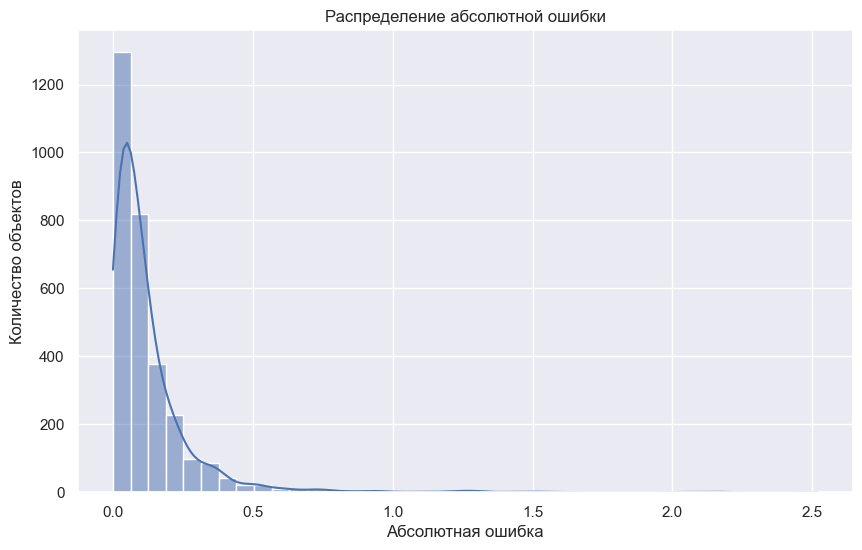

In [87]:
# Визуализируем распределение абсолютной ошибки
plt.figure(figsize=(10, 6))

sns.histplot(errors_df['abs_error'], bins=40, kde=True)

plt.title('Распределение абсолютной ошибки')
plt.xlabel('Абсолютная ошибка')
plt.ylabel('Количество объектов')
plt.show()

In [88]:
# Смотрим самые большие ошибки модели
error_view_cols = [
    'true_rating',
    'pred_rating',
    'error',
    'abs_error',
    'BGG Rank',
    'Users Rated',
    'Owned Users',
    'Complexity Average',
    'Year Published',
    'Min Players',
    'Max Players',
    'Play Time',
    'Min Age'
]

errors_df[error_view_cols].sort_values('abs_error', ascending=False).head(15)

,true_rating,pred_rating,error,abs_error,BGG Rank,Users Rated,Owned Users,Complexity Average,Year Published,Min Players,Max Players,Play Time,Min Age
10919,9.19,6.671144,2.518856,2.518856,14547,34,44.0,1.00,2020.0,2.0,5,60,8
11743,8.71,6.537744,2.172256,2.172256,15683,43,31.0,2.00,2020.0,2.0,0,60,14
15215,1.10,3.241745,-2.141745,2.141745,20288,263,12.0,1.00,2019.0,2.0,7,40,14
11477,8.76,6.673943,2.086057,2.086057,15322,36,22.0,1.00,2017.0,2.0,5,50,8
5762,8.26,6.243884,2.016116,2.016116,7741,231,302.0,1.50,2014.0,2.0,6,10,8
15253,2.28,3.888940,-1.608940,1.608940,20340,1340,427.0,1.00,NaN,2.0,2,30,4
12861,7.00,5.475184,1.524816,1.524816,17162,80,113.0,1.75,2001.0,2.0,2,75,10
9980,9.05,7.540745,1.509255,1.509255,13294,34,55.0,3.75,2011.0,2.0,8,480,12
11007,7.64,6.185923,1.454077,1.454077,14665,49,NaN,3.00,2017.0,2.0,6,90,10
10701,8.44,7.034140,1.405860,1.405860,14263,81,19.0,3.59,2016.0,3.0,5,120,14


# Анализируем ошибки по диапазонам рейтинга

Проверим, одинаково ли хорошо модель работает для разных уровней рейтинга.

Разобьем игры на группы:

- низкий рейтинг
- средний рейтинг
- высокий рейтинг

In [89]:
# Создаем интервалы рейтинга
errors_df['rating_group'] = pd.cut(
    errors_df['true_rating'],
    bins=[0, 5.5, 6.5, 7.5, 10],
    labels=[
        'low_rating',
        'middle_rating',
        'good_rating',
        'high_rating'
    ]
)

# Считаем ошибки по группам
rating_group_errors = (
    errors_df
    .groupby('rating_group', observed=True)
    .agg(
        objects_count=('abs_error', 'count'),
        mae=('abs_error', 'mean'),
        median_error=('abs_error', 'median'),
        max_error=('abs_error', 'max'),
        mean_true_rating=('true_rating', 'mean'),
        mean_pred_rating=('pred_rating', 'mean')
    )
    .sort_values('mae', ascending=False)
)

rating_group_errors

,objects_count,mae,median_error,max_error,mean_true_rating,mean_pred_rating
rating_group,,,,,,
high_rating,353,0.255921,0.149630,2.518856,7.923003,7.754730
good_rating,1087,0.120771,0.085123,1.524816,6.948473,6.956820
low_rating,459,0.114214,0.065276,2.141745,4.872854,4.900413
middle_rating,1153,0.092519,0.066842,0.801817,6.060694,6.092542


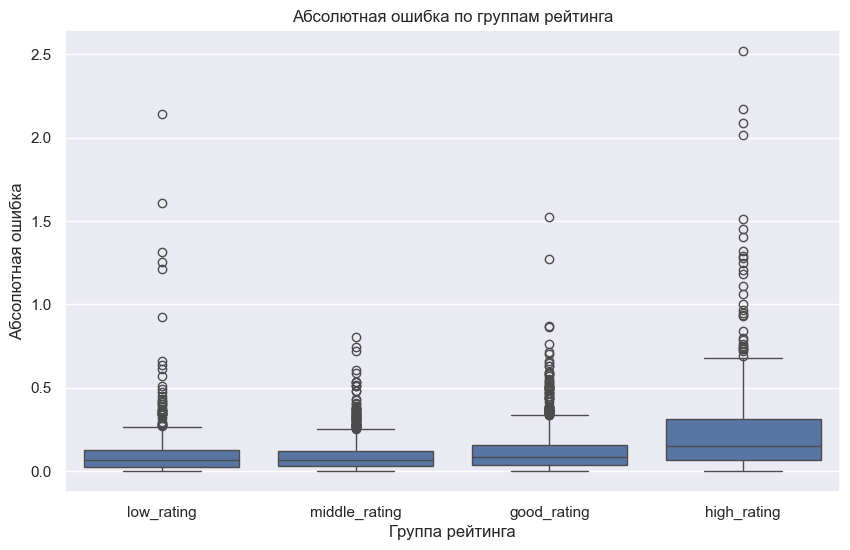

In [90]:
# Визуализируем ошибку по группам рейтинга
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=errors_df,
    x='rating_group',
    y='abs_error'
)

plt.title('Абсолютная ошибка по группам рейтинга')
plt.xlabel('Группа рейтинга')
plt.ylabel('Абсолютная ошибка')
plt.show()

# Анализируем ошибки по количеству оценок

Рейтинг игр с малым количеством оценок может быть менее стабильным.
Проверим, зависит ли ошибка модели от количества пользователей, которые оценили игру.

In [91]:
# Создаем интервалы по количеству оценок
errors_df['users_rated_group'] = pd.qcut(
    errors_df['Users Rated'],
    q=5,
    duplicates='drop'
)

users_rated_errors = (
    errors_df
    .groupby('users_rated_group', observed=True)
    .agg(
        objects_count=('abs_error', 'count'),
        mae=('abs_error', 'mean'),
        median_error=('abs_error', 'median'),
        max_error=('abs_error', 'max'),
        mean_users_rated=('Users Rated', 'mean')
    )
    .sort_values('mae', ascending=False)
)

users_rated_errors

,objects_count,mae,median_error,max_error,mean_users_rated
users_rated_group,,,,,
"(29.999, 49.0]",619,0.185416,0.112617,2.518856,38.657512
"(49.0, 89.0]",610,0.136551,0.085772,1.524816,67.452459
"(89.0, 186.0]",603,0.118599,0.077889,1.290039,129.091211
"(186.0, 526.6]",609,0.097093,0.064962,2.141745,310.937603
"(526.6, 43165.0]",611,0.085110,0.059939,1.608940,3515.000000


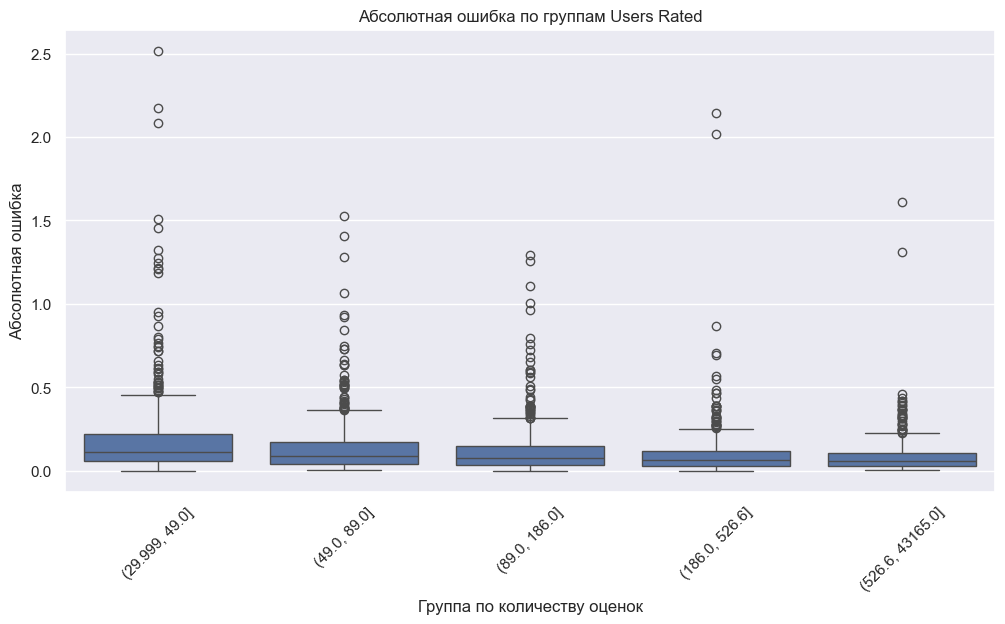

In [92]:
# Визуализируем ошибку по количеству оценок
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=errors_df,
    x='users_rated_group',
    y='abs_error'
)

plt.title('Абсолютная ошибка по группам Users Rated')
plt.xlabel('Группа по количеству оценок')
plt.ylabel('Абсолютная ошибка')
plt.xticks(rotation=45)
plt.show()

## Выводы после анализа

Модель качественная, но у нее есть слабые места:

1. High-rating игры -> модель склонна занижать высокие оценки
2. Игры с малым числом оценок -> рейтинг менее стабильный, ошибка выше

# Собираем и обучаем окончательный вариант модели

In [93]:
# Проверяем совпадение колонок
missing_cols_in_test = set(X.columns) - set(X_test.columns)
missing_cols_in_train = set(X_test.columns) - set(X.columns)

# Смотрим, есть ли пропуски
print('Missing in test:', missing_cols_in_test)
print('Missing in train:', missing_cols_in_train)

print(f'X shape: {X.shape}')
print(f'X_test shape: {X_test.shape}')

Missing in test: set()
Missing in train: set()
X shape: (15257, 79)
X_test shape: (5086, 79)


In [94]:
# Берем лучшую модель и переобучаем на всех train данных

# Берем лучший pipeline по валидационной выборке
final_pipeline = clone(best_pipeline)

# Обучаем финальную модель на всех тренировочных данных
final_pipeline.fit(X, y)

print(f'Final model trained: {best_model_name}')

Final model trained: HistGradientBoostingRegressor


In [95]:
# Предсказываем рейтинг для тестового набора
test_predict = final_pipeline.predict(X_test)

# На всякий случай ограничиваем рейтинг допустимым диапазоном
test_predict = np.clip(test_predict, 1, 10)

# Выводим первые предсказания из массива
test_predict[:10]

array([8.07609436, 7.9706892 , 8.1359808 , 8.29395974, 8.03499192,
       8.10714015, 8.27134831, 8.162972  , 8.27123027, 8.28347657])

# Файл с результатом обучения для Kaggle

In [96]:
# Собираем файл для Kaggle
submission = pd.DataFrame({
    'index': test.index,
    'Rating Average': test_predict
})

submission.head()

,index,Rating Average
0,0,8.076094
1,1,7.970689
2,2,8.135981
3,3,8.293960
4,4,8.034992


In [97]:
# Проверяем submission перед сохранением
print(f'Submission shape: {submission.shape}')
print()
print(submission.isna().sum())
print()
print(submission.dtypes)

submission.head()

Submission shape: (5086, 2)

index             0
Rating Average    0
dtype: int64

index               int64
Rating Average    float64
dtype: object


,index,Rating Average
0,0,8.076094
1,1,7.970689
2,2,8.135981
3,3,8.293960
4,4,8.034992


In [98]:
# Сохраняем файл для отправки на Kaggle
submission.to_csv('submission.csv', index=False)
print('Файл submission.csv успешно сохранен')

Файл submission.csv успешно сохранен


# Итоговые выводы о проделанной работе

В ходе работы была построена модель для предсказания среднего рейтинга настольных игр `Rating Average`.

Что было сделано:

1. Загружены и изучены тренировочный и тестовый датасеты:
   - в тренировочном наборе есть целевая переменная `Rating Average`
   - в тестовом наборе целевая переменная отсутствует, поэтому он использовался только для финального предсказания

2. Проведена первичная обработка данных:
   - признаки `Rating Average` и `Complexity Average` были преобразованы из строкового формата в числовой
   - обработаны некорректные значения в `Year Published`, `Min Players`, `Max Players`, `Play Time`
   - для аномальных значений были добавлены отдельные флаги

3. Проведен анализ данных:
   - целевая переменная имеет распределение, которое склоняется нормальному
   - наиболее сильная связь с рейтингом наблюдается у признака `BGG Rank`
   - полезными признаками оказались сложность, популярность и количество оценок

4. Созданы дополнительные признаки:
   - логарифмированные признаки `log_users_rated`, `log_owned_users`, `log_play_time`
   - признаки по количеству игроков: `players_range`, `is_solo_game`, `is_party_like_game`

5. Категориальные мультипризнаки `Mechanics` и `Domains` обработаны следующим образом:
   - для `Mechanics` выбраны наиболее частые значения
   - для `Domains` закодированы все доступные значения

6. Обучены и сравнены следующие модели:
   - `DummyRegressor`
   - `DecisionTreeRegressor`
   - `RandomForestRegressor`
   - `ExtraTreesRegressor`
   - `HistGradientBoostingRegressor`

7. Для оценки качества использовались метрики:
   - `MAE`
   - `MSE`
   - `R2`

Лучший результат показала модель `HistGradientBoostingRegressor`

Итоговое качество на валидационной выборке:

- `MAE` ~0.125
- `MSE` ~0.046
- `R2` ~0.949

Таким образом, модель в среднем ошибается примерно на 0.125 рейтингового балла, а также объясняет около 95% разброса целевой переменной

После анализа ошибок было выявлено, что модель чаще ошибается:

- на играх с очень высоким рейтингом
- на играх с малым количеством оценок
- на отдельных выбросах, где фактический рейтинг сильно отличается от ожидаемого по признакам

Финальная модель обучена на всех тренировочных данных, после чего сделаны предсказания для тестового набора.
Результаты были сохранены в файл `submission.csv` и загружены на Kaggle.

Публичный результат на Kaggle составил MSE ~0.04792
Модель не переобучилась и хорошо обобщается на новых данных